<a href="https://colab.research.google.com/github/MuhammadAhmedMasood/deep-learning-pytorch/blob/main/02_PyTorch_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02. Neural Network classification with PyTorch

Classification is a problem of predicting whether something is one thing or another.

In [3]:
# make classification data:
import sklearn

In [4]:
from sklearn.datasets import make_circles
n_samples = 1000

X, y = make_circles(n_samples, noise = 0.003, random_state = 42)

len(X), len(y)

(1000, 1000)

In [5]:
print(X[:5])
print(f"\n{y[:5]}")

[[ 0.77049941  0.21095396]
 [-0.78602977  0.13242465]
 [-0.79586178  0.10756813]
 [-0.34593416  0.72076375]
 [ 0.43762495 -0.89913707]]

[1 1 1 1 0]


In [6]:
print(y)

[1 1 1 1 0 1 1 1 1 0 1 0 1 1 1 1 0 1 1 0 1 0 0 1 0 0 0 1 1 1 0 0 1 0 0 0 1
 1 1 0 0 0 0 1 0 0 1 1 0 1 1 1 0 1 0 0 1 0 0 1 0 0 1 0 1 1 1 1 0 1 0 0 1 1
 0 0 1 0 1 0 1 0 0 0 0 1 1 1 1 0 0 0 1 0 1 0 1 0 0 1 1 0 1 0 1 1 1 1 0 1 1
 1 1 1 0 0 0 1 1 0 1 0 1 0 0 1 1 0 1 1 1 1 0 1 1 0 0 0 0 0 0 0 1 0 1 1 1 0
 1 0 1 0 1 0 1 0 0 1 0 1 1 1 1 1 1 1 0 1 0 0 0 0 0 1 0 0 0 0 1 1 0 1 0 1 1
 0 0 0 1 1 1 1 1 0 0 0 0 0 1 0 0 1 1 1 1 1 0 1 0 1 0 0 1 1 1 0 1 0 1 1 0 1
 1 0 1 0 1 0 1 1 0 1 0 1 0 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 1 0 0 1 1 1
 0 1 0 0 0 0 1 1 0 1 0 0 0 1 0 1 0 0 1 0 1 1 1 0 0 0 1 0 0 0 1 1 1 1 0 0 0
 1 0 0 0 1 0 0 0 1 1 0 1 1 1 1 1 1 1 0 0 0 0 1 0 0 0 0 1 1 1 0 0 1 0 1 0 1
 1 0 0 1 1 1 1 0 0 0 0 0 0 1 1 0 1 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1
 0 1 0 0 0 1 0 0 1 1 0 0 1 0 0 1 1 0 1 1 0 0 1 0 1 0 0 0 1 1 0 0 1 1 1 1 1
 0 0 1 1 1 1 0 1 1 1 1 1 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 1 0 1 1 1
 1 1 1 0 1 1 1 1 0 0 0 1 1 1 0 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 1 1 1 1 1 1
 0 0 0 1 0 0 0 0 0 1 1 1 

In [7]:
# Make a DataFrame:

import pandas as pd

df = pd.DataFrame({
    "X1": X[:,0],
    "X2": X[:,1],
    "label" : y
})
df.head(10)

,X1,X2,label
0,0.770499,0.210954,1
1,-0.786030,0.132425,1
2,-0.795862,0.107568,1
3,-0.345934,0.720764,1
4,0.437625,-0.899137,0
5,-0.492824,0.633771,1
6,-0.010412,0.800278,1
7,0.787565,0.131875,1
8,-0.160723,-0.784841,1
9,-0.136160,0.993566,0


In [8]:
df.label.value_counts()

,count
label,
1,500
0,500


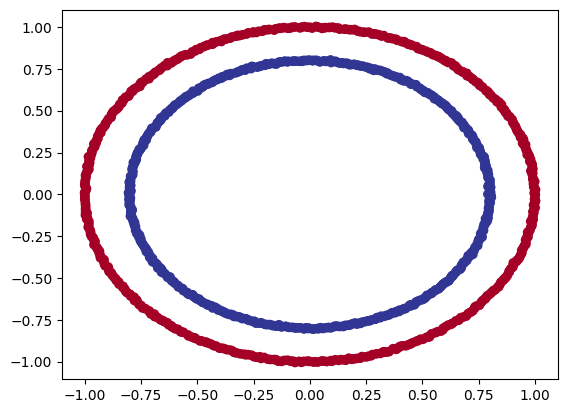

In [9]:
import matplotlib.pyplot as plt

plt.scatter(X[:,0], X[:,1],c=y,cmap = plt.cm.RdYlBu )

In [10]:
X.shape, y.shape

((1000, 2), (1000,))

In [11]:
X

array([[ 0.77049941,  0.21095396],
       [-0.78602977,  0.13242465],
       [-0.79586178,  0.10756813],
       ...,
       [-0.14860458, -0.788248  ],
       [ 0.68312855, -0.73282192],
       [ 0.284623  ,  0.95905205]])

In [12]:
X_sample = X[0]
y_sample = y[0]
print(f"values for one sample of: {X_sample} and the same for y: {y_sample}")
print(f"Shapes for one sample of: {X_sample.shape} and the same for y: {y_sample.shape}")

values for one sample of: [0.77049941 0.21095396] and the same for y: 1
Shapes for one sample of: (2,) and the same for y: ()


In [13]:
# getting into tensors and train test split:
import torch
torch.__version__

'2.11.0+cpu'

In [14]:
type(X)

numpy.ndarray

In [15]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X[:5], y[:5]

(tensor([[ 0.7705,  0.2110],
         [-0.7860,  0.1324],
         [-0.7959,  0.1076],
         [-0.3459,  0.7208],
         [ 0.4376, -0.8991]]),
 tensor([1., 1., 1., 1., 0.]))

In [16]:
X.dtype, y.dtype

(torch.float32, torch.float32)

In [17]:
# split data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [18]:
# split data
from sklearn.model_selection import train_test_split

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [19]:
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [20]:
import torch
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [21]:
X_train_new

tensor([[ 0.6319, -0.4914],
        [ 0.6710, -0.7372],
        [-0.9906, -0.1476],
        ...,
        [ 0.0355, -1.0024],
        [ 0.9909,  0.1520],
        [ 0.5552, -0.5757]])

In [22]:
X_train

tensor([[ 0.6319, -0.4914],
        [ 0.6710, -0.7372],
        [-0.9906, -0.1476],
        ...,
        [ 0.0355, -1.0024],
        [ 0.9909,  0.1520],
        [ 0.5552, -0.5757]])

The device agnostic code is setup.

We'll create a model that:
1. Subclasses `nn.Module` (almost all models in PyTorch subclass `nn.Module`)
2. Create 2 `nn.Linear()` layers that are capable of handling the shape of our data
3. Define a `forward()` method that outlines the forward pass (forward propagation of the model
4. Instantiate an instance of our model and send it to the target `device`

In [23]:
class CircleModelV0(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=5)
    self.layer_2 = nn.Linear(in_features=5, out_features=1)
  def forward(self, x: torch.tensor):
    return self.layer_2(self.layer_1(x)) # x -> self.layer_1 -> self.layer_2

model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [24]:
device

'cpu'

In [25]:
next(model_0.parameters()).device

device(type='cpu')

In [26]:
# using nn.Sequential:

model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
).to(device)
model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [27]:
# can also fit the nn.Sequential in the class itself as well. Knowing how to use the class approach is impt when we more complex forward method

In [28]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.6858, -0.3730],
                      [-0.6750,  0.5013],
                      [-0.1482, -0.1294],
                      [ 0.2325, -0.3767],
                      [ 0.6629, -0.6372]])),
             ('0.bias', tensor([ 0.1083,  0.3426, -0.3597,  0.7004,  0.0236])),
             ('1.weight',
              tensor([[-0.4442,  0.2421, -0.4178, -0.4389,  0.2564]])),
             ('1.bias', tensor([-0.1644]))])

In [29]:
# Making predictions
with torch.inference_mode():
  untrained_preds = model_0(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(X_test)}, Shape: {X_test.shape}")
print(f"\nFirst 10 predictions:\n{torch.round(untrained_preds[:10])}")
print(f"\nFirst 10 labels:\n{y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200, 2])

First 10 predictions:
tensor([[-0.],
        [ 0.],
        [-1.],
        [-0.],
        [-0.],
        [-0.],
        [ 0.],
        [ 0.],
        [-1.],
        [ 0.]])

First 10 labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [30]:
X_test[:10], y_test[:10]

(tensor([[-0.3923,  0.6948],
         [-0.0437,  0.9949],
         [-0.7256, -0.3298],
         [-0.3281,  0.9453],
         [ 0.4260, -0.6823],
         [ 0.6180, -0.5161],
         [ 0.8268,  0.5655],
         [ 0.9844,  0.1877],
         [-0.7676, -0.2260],
         [ 0.0619,  0.9956]]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

In [31]:
# Setup loss function and optimizer

# regression -> MAE (L1 loss) or MSE
# classification -> binary cross entropy or categorical cross entropy

# For optimzers, 2 most common are: SGD or Adam


loss_fn = nn.BCEWithLogitsLoss() # sigmoid activation function is built-in. This is similar to having inputs going to sigmoid and then BCELoss:

# nn.Sequential(nn.Sigmoid(), nn.BCELoss())
# The reason we use nn.BCEWithLogitsLoss() is it has more numerical stability, see PyTorch documentation

optimizer = torch.optim.SGD(params = model_0.parameters(), lr = 0.1)

In [32]:
# accuracy - TP/TP+FP * 100

def accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  acc = (correct/len(y_pred)) * 100
  return acc

In [33]:
# our model's outputs are logits - and we can convert them to prediction probabilities by passing through some activation function
# for example, sigmoid for binary classification, softmax for multiclass classification
# then we convert our model's predictions to prediction labels by either rounding them up or using argmax()

In [34]:
# viewing the first 5 outputs of the forward pass on the test data:
model_0.eval()
with torch.inference_mode():
  y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[-0.1486],
        [ 0.0488],
        [-0.5904],
        [-0.0452],
        [-0.3992]])

In [35]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [36]:
# using sigmoid on our logits:
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4629],
        [0.5122],
        [0.3565],
        [0.4887],
        [0.4015]])

In [37]:
y_preds = torch.round(y_pred_probs)
y_preds

tensor([[0.],
        [1.],
        [0.],
        [0.],
        [0.]])

In [38]:
# in full:
y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

# check equality
print(torch.eq(y_pred_labels.squeeze(), y_preds.squeeze()))
y_preds.squeeze()

tensor([True, True, True, True, True])


tensor([0., 1., 0., 0., 0.])

In [39]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [40]:
# Training

torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 200

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):

  model_0.train()

  # Feed Forward
  y_logits = model_0(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits)) # turn logits -> pred probs -> pred labels


  # calculate loss/ accuracy

  # loss = loss_fn(torch.sigmoid(y_logits), # nn.BCELoss expects prediction probabilities as input
  #               y_train)

  loss = loss_fn(y_logits, # nn.BCEWithLogitsLoss expects raw logits as input
                 y_train)
  acc = accuracy_fn(y_true = y_train, y_pred = y_pred)

  # optimizer
  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  # testing
  model_0.eval()
  with torch.inference_mode():
    test_logits = model_0(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits,
                        y_test)
    test_acc = accuracy_fn(y_true = y_test,
                           y_pred = test_pred)

    if epoch % 10 == 0:
      print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.71024, Acc: 46.12% | Test loss: 0.72024, Test acc: 48.00%
Epoch: 10 | Loss: 0.70127, Acc: 48.62% | Test loss: 0.71162, Test acc: 47.00%
Epoch: 20 | Loss: 0.69799, Acc: 49.50% | Test loss: 0.70786, Test acc: 46.50%
Epoch: 30 | Loss: 0.69651, Acc: 50.38% | Test loss: 0.70568, Test acc: 46.00%
Epoch: 40 | Loss: 0.69567, Acc: 50.62% | Test loss: 0.70414, Test acc: 46.50%
Epoch: 50 | Loss: 0.69510, Acc: 50.75% | Test loss: 0.70291, Test acc: 46.00%
Epoch: 60 | Loss: 0.69469, Acc: 51.00% | Test loss: 0.70189, Test acc: 46.00%
Epoch: 70 | Loss: 0.69436, Acc: 51.25% | Test loss: 0.70103, Test acc: 45.50%
Epoch: 80 | Loss: 0.69410, Acc: 51.25% | Test loss: 0.70029, Test acc: 46.00%
Epoch: 90 | Loss: 0.69390, Acc: 51.25% | Test loss: 0.69965, Test acc: 46.00%
Epoch: 100 | Loss: 0.69373, Acc: 51.25% | Test loss: 0.69910, Test acc: 46.00%
Epoch: 110 | Loss: 0.69360, Acc: 51.12% | Test loss: 0.69862, Test acc: 46.00%
Epoch: 120 | Loss: 0.69349, Acc: 51.25% | Test loss: 0.69819, T

In [41]:
# predictions and evaluate
import requests
from pathlib import Path

if Path("helper_function.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

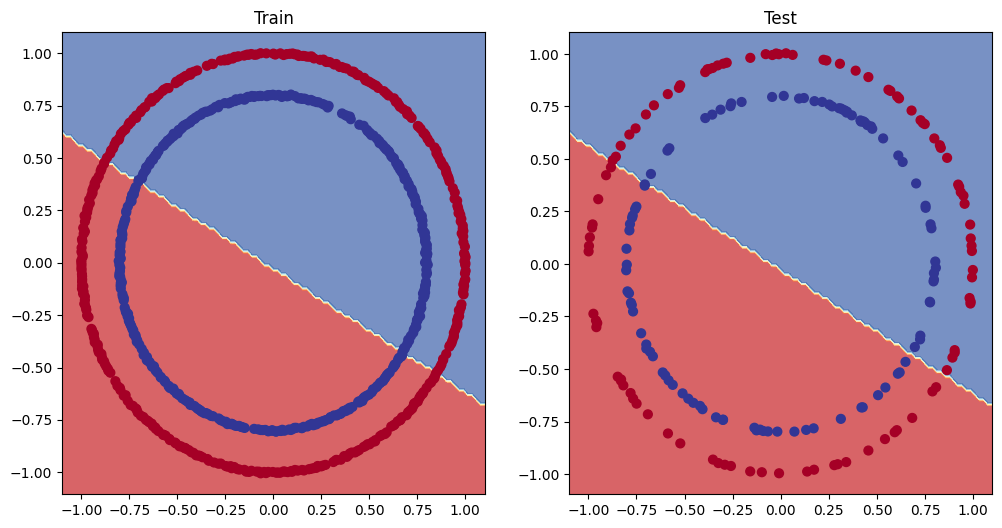

In [42]:
plt.figure(figsize = (12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

In [43]:
# improving a model:

# add more layers - give model more chances to learn
# add more hidden units
# fit for longer
# changing activation functions
# changing learning rate
# changing loss function

# these are from model's perspectives as it deals with the model directly and not data

In [44]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.6249, -0.2928],
                      [-0.7257,  0.4336],
                      [-0.0705, -0.0260],
                      [ 0.2973, -0.2908],
                      [ 0.6128, -0.7040]])),
             ('0.bias', tensor([ 0.0641,  0.3706, -0.4057,  0.6577,  0.0515])),
             ('1.weight',
              tensor([[-0.2382,  0.2940, -0.4202, -0.3344,  0.3058]])),
             ('1.bias', tensor([-0.0574]))])

In [45]:
# improving the model:

In [46]:
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features = 2, out_features = 10)
    self.layer_2 = nn.Linear(in_features = 10, out_features = 10)
    self.layer_3 = nn.Linear(in_features = 10, out_features = 1)

  def forward(self, x):
    # z = self.layer_1(x)
    # z = self.layer_2(z)
    # z = self.layer_3(z)
    return self.layer_3(self.layer_2(self.layer_1(x))) # leverages speed behind the scenes by writing like this
model_1 = CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [47]:
model_1.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188],
                      [ 0.6146,  0.1323],
                      [ 0.5224,  0.0958],
                      [ 0.3410, -0.0998],
                      [ 0.5451,  0.1045],
                      [-0.3301,  0.1802]])),
             ('layer_1.bias',
              tensor([-0.3258, -0.0829, -0.2872,  0.4691, -0.5582, -0.3260, -0.1997, -0.4252,
                       0.0667, -0.6984])),
             ('layer_2.weight',
              tensor([[ 0.2856, -0.2686,  0.2441,  0.0526, -0.1027,  0.1954,  0.0493,  0.2555,
                        0.0346, -0.0997],
                      [ 0.0850, -0.0858,  0.1331,  0.2823,  0.1828, -0.1382,  0.1825,  0.0566,
                        0.1606, -0.1927],
                      [-0.3130, -0.1222, -0.2426,  0.2595,  0.0911,  0.1

In [48]:
loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(params = model_1.parameters(), lr = 0.1)

In [49]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000

X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):

  model_1.train()

  y_logits = model_1(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  loss = loss_fn(y_logits, y_train)

  acc = accuracy_fn(y_true = y_train, y_pred = y_pred)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_1.eval()

  with torch.inference_mode():
    test_logits = model_1(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_true = y_test, y_pred = test_pred)

    if epoch % 100 == 0:
      print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")


Epoch: 0 | Loss: 0.69399, Acc: 50.75% | Test Loss: 0.69259, Test acc: 50.50%
Epoch: 100 | Loss: 0.69305, Acc: 50.62% | Test Loss: 0.69379, Test acc: 47.00%
Epoch: 200 | Loss: 0.69298, Acc: 51.12% | Test Loss: 0.69439, Test acc: 45.50%
Epoch: 300 | Loss: 0.69298, Acc: 51.12% | Test Loss: 0.69459, Test acc: 45.50%
Epoch: 400 | Loss: 0.69298, Acc: 51.12% | Test Loss: 0.69466, Test acc: 45.50%
Epoch: 500 | Loss: 0.69298, Acc: 51.12% | Test Loss: 0.69469, Test acc: 45.50%
Epoch: 600 | Loss: 0.69298, Acc: 51.12% | Test Loss: 0.69469, Test acc: 45.50%
Epoch: 700 | Loss: 0.69298, Acc: 51.12% | Test Loss: 0.69470, Test acc: 45.50%
Epoch: 800 | Loss: 0.69298, Acc: 51.12% | Test Loss: 0.69470, Test acc: 45.50%
Epoch: 900 | Loss: 0.69298, Acc: 51.12% | Test Loss: 0.69470, Test acc: 45.50%


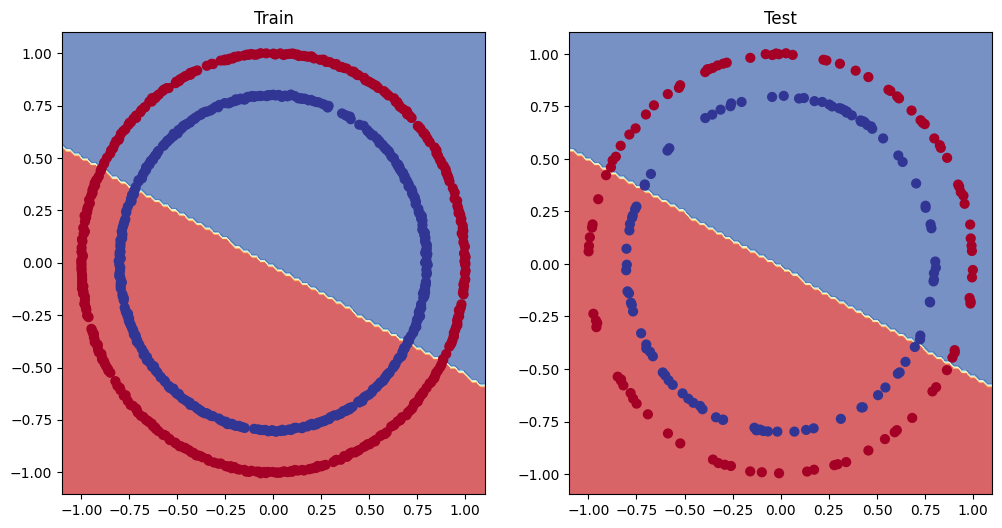

In [50]:
plt.figure(figsize = (12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

In [51]:
# lets see if our model fits a straight line:
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.01

X_regression = torch.arange(start, end, step).unsqueeze(dim = 1)
y_regression = weight*X_regression + bias

print(len(X_regression))
X_regression[:5], y_regression[:5]

100


(tensor([[0.0000],
         [0.0100],
         [0.0200],
         [0.0300],
         [0.0400]]),
 tensor([[0.3000],
         [0.3070],
         [0.3140],
         [0.3210],
         [0.3280]]))

In [52]:
train_split = int(0.8*len(X_regression))
X_train_regression, y_train_regression = X_regression[:train_split], y_regression[:train_split]
X_test_regression, y_test_regression = X_regression[train_split:], y_regression[train_split:]

len(X_train_regression), len(y_train_regression), len(X_test_regression), len(y_test_regression)

(80, 80, 20, 20)

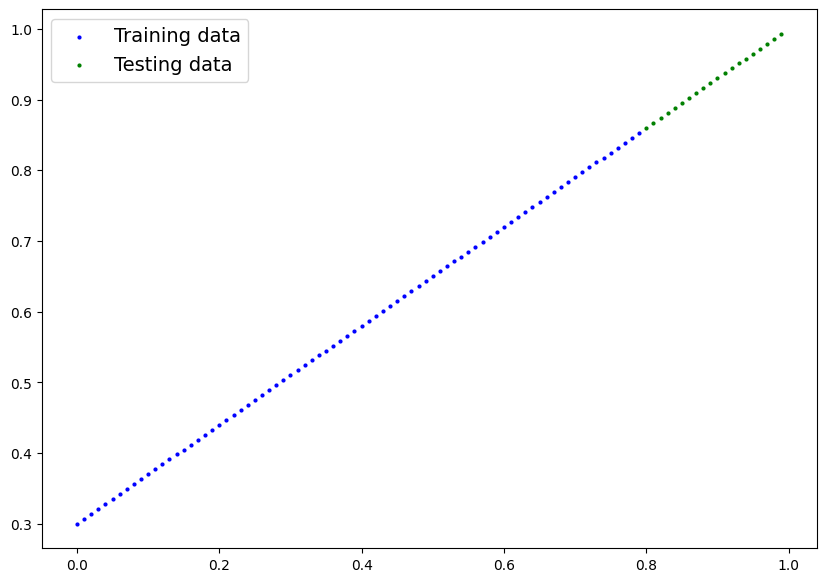

In [53]:
plot_predictions(train_data = X_train_regression, train_labels = y_train_regression, test_data = X_test_regression, test_labels = y_test_regression)

In [54]:
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [55]:
model_2 = nn.Sequential(
    nn.Linear(in_features = 1, out_features = 10),
    nn.Linear(in_features = 10, out_features = 10),
    nn.Linear(in_features = 10, out_features = 1)
).to(device)

In [56]:
model_2

Sequential(
  (0): Linear(in_features=1, out_features=10, bias=True)
  (1): Linear(in_features=10, out_features=10, bias=True)
  (2): Linear(in_features=10, out_features=1, bias=True)
)

In [57]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params = model_2.parameters(), lr = 0.01)

In [58]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000
X_train_regression, y_train_regression = X_train_regression.to(device), y_train_regression.to(device)
X_test_regression, y_test_regression = X_test_regression.to(device), y_test_regression.to(device)

for epoch in range(epochs):
  model_2.train()

  y_pred = model_2(X_train_regression)
  loss = loss_fn(y_pred, y_train_regression)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_2.eval()
  with torch.inference_mode():
    test_pred = model_2(X_test_regression)
    test_loss = loss_fn(test_pred, y_test_regression)

  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Test Loss: {test_loss:.2f}")

Epoch: 0 | Loss: 0.75986 | Test Loss: 0.91
Epoch: 100 | Loss: 0.02858 | Test Loss: 0.00
Epoch: 200 | Loss: 0.02533 | Test Loss: 0.00
Epoch: 300 | Loss: 0.02137 | Test Loss: 0.00
Epoch: 400 | Loss: 0.01964 | Test Loss: 0.00
Epoch: 500 | Loss: 0.01940 | Test Loss: 0.00
Epoch: 600 | Loss: 0.01903 | Test Loss: 0.00
Epoch: 700 | Loss: 0.01878 | Test Loss: 0.00
Epoch: 800 | Loss: 0.01840 | Test Loss: 0.00
Epoch: 900 | Loss: 0.01798 | Test Loss: 0.00


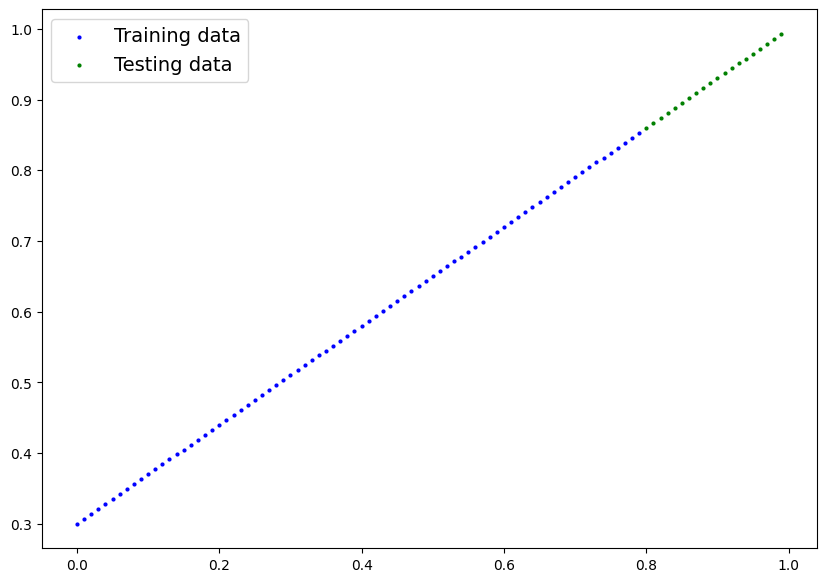

In [59]:
model_2.eval()
with torch.inference_mode():
  y_preds = model_2(X_test_regression)

plot_predictions(train_data = X_train_regression.cpu(), train_labels = y_train_regression.cpu(), test_data = X_test_regression.cpu(),test_labels=y_test_regression.cpu())

In [60]:
# non-linearity
from torch import nn
class CircleModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features = 2, out_features = 10)
    self.layer_2 = nn.Linear(in_features = 10, out_features = 10)
    self.layer_3 = nn.Linear(in_features = 10, out_features = 1)
    self.relu = nn.ReLU()
  def forward(self, x):
    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

model_3 = CircleModelV2().to(device)
model_3

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [61]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params = model_3.parameters(), lr = 0.1)


In [62]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

X_train_new, y_train_new = X_train_new.to(device), y_train_new.to(device)
X_test_new, y_test_new = X_test_new.to(device), y_test_new.to(device)

epochs = 1000

for epoch in range(epochs):
  model_3.train()
  y_logits = model_3(X_train_new).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  loss = loss_fn(y_logits, y_train_new)
  acc = accuracy_fn(y_true = y_train_new, y_pred = y_pred)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_3.eval()
  with torch.inference_mode():
    test_logits = model_3(X_test_new).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    test_loss = loss_fn(test_logits, y_test_new)
    test_acc = accuracy_fn(y_true = y_test_new, y_pred = test_pred)

    if epoch % 100 == 0:
      print(f"Epoch: {epoch} | Loss: {loss:.4f} | Acc: {acc:.2f}% | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.6930 | Acc: 50.00% | Test Loss: 0.6930 | Test Acc: 50.00%
Epoch: 100 | Loss: 0.6912 | Acc: 53.25% | Test Loss: 0.6907 | Test Acc: 54.00%
Epoch: 200 | Loss: 0.6898 | Acc: 53.25% | Test Loss: 0.6890 | Test Acc: 55.50%
Epoch: 300 | Loss: 0.6881 | Acc: 53.25% | Test Loss: 0.6866 | Test Acc: 57.00%
Epoch: 400 | Loss: 0.6853 | Acc: 53.25% | Test Loss: 0.6831 | Test Acc: 57.00%
Epoch: 500 | Loss: 0.6812 | Acc: 53.12% | Test Loss: 0.6778 | Test Acc: 57.00%
Epoch: 600 | Loss: 0.6754 | Acc: 53.62% | Test Loss: 0.6705 | Test Acc: 58.50%
Epoch: 700 | Loss: 0.6666 | Acc: 57.38% | Test Loss: 0.6594 | Test Acc: 63.00%
Epoch: 800 | Loss: 0.6517 | Acc: 64.25% | Test Loss: 0.6427 | Test Acc: 70.50%
Epoch: 900 | Loss: 0.6237 | Acc: 73.75% | Test Loss: 0.6144 | Test Acc: 78.50%


In [63]:
model_3.eval()
with torch.inference_mode():
  y_preds = torch.round(torch.sigmoid(model_3(X_test_new))).squeeze()
y_preds[:10], y_test[:10]

(tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

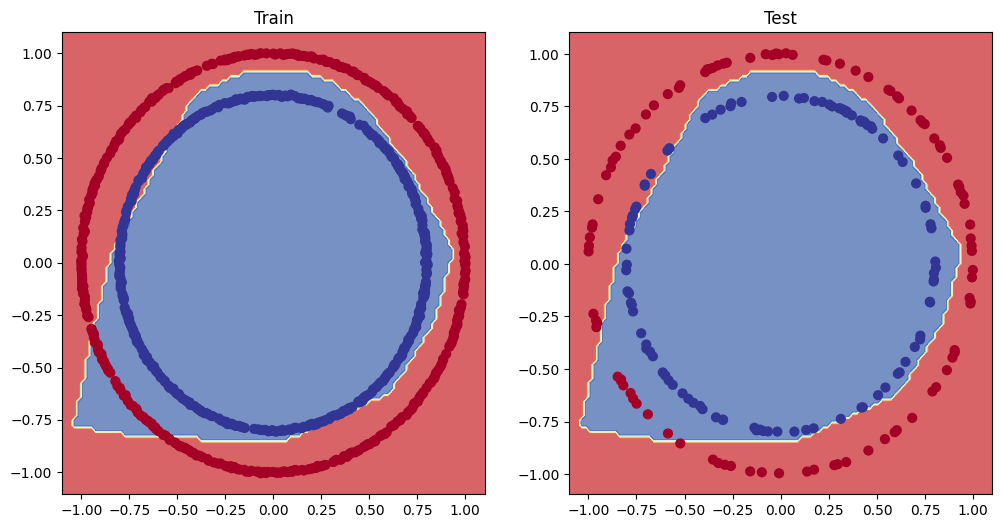

In [64]:
plt.figure(figsize = (12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_3, X_train_new, y_train_new)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_3,X_test_new, y_test_new)

In [65]:
# multi class classification

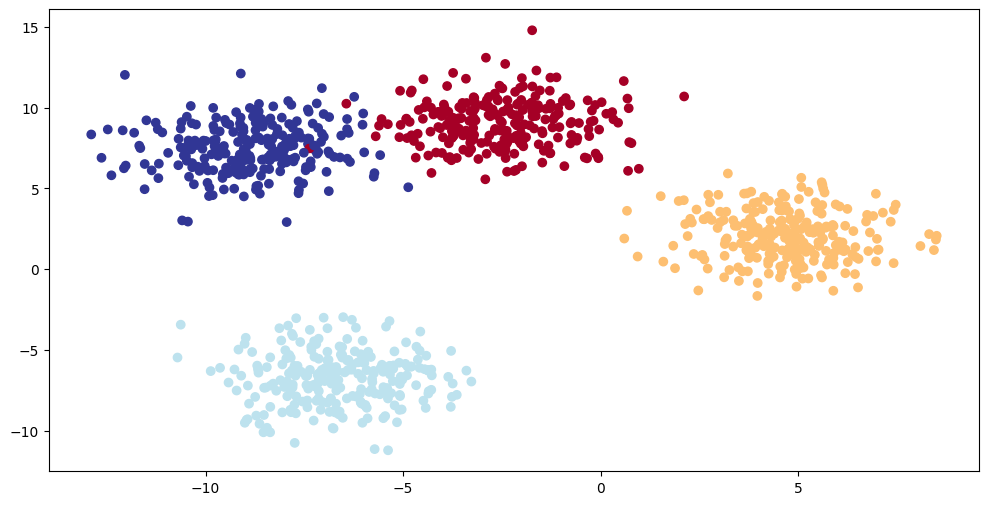

In [66]:
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

X_blob, y_blob = make_blobs(n_samples = 1000, n_features = NUM_FEATURES, centers = NUM_CLASSES, cluster_std = 1.5, random_state = RANDOM_SEED)

X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.float)

X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob, y_blob, test_size = 0.2, random_state = RANDOM_SEED)

plt.figure(figsize = (12,6))
plt.scatter(X_blob[:,0], X_blob[:,1], c = y_blob, cmap = plt.cm.RdYlBu)


In [67]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [75]:
class BlobModel(nn.Module):
  def __init__(self, input_features, output_features, hidden_units = 8):
    super().__init__()
    self.linear_stack = nn.Sequential(
        nn.Linear(in_features = input_features, out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features = hidden_units, out_features = hidden_units),
        nn.ReLU(),
        nn.Linear(in_features = hidden_units, out_features = output_features)
    )
  def forward(self,x):
    return self.linear_stack(x)
model_4 = BlobModel(input_features = 2, output_features = 4, hidden_units = 8).to(device)
model_4

BlobModel(
  (linear_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [76]:
X_blob_train.shape, y_blob_train[:5]

(torch.Size([800, 2]), tensor([1., 0., 2., 2., 0.]))

In [77]:
torch.unique(y_blob_train)

tensor([0., 1., 2., 3.])

In [78]:
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params = model_4.parameters(), lr = 0.1)

In [81]:
model_4.eval()
with torch.inference_mode():
  y_logits = model_4(X_blob_test.to(device))
y_logits[:10]

tensor([[ 0.7111, -0.5330,  0.3307, -0.2327],
        [-0.3420, -1.7850, -0.3224, -1.1384],
        [ 0.1878, -0.8563,  0.3375, -0.9026],
        [ 0.4513, -0.4277,  0.2498, -0.1940],
        [ 0.8922, -0.9492,  0.3245, -0.5287],
        [-0.4885, -2.0119, -0.4004, -1.3252],
        [ 0.2586, -0.8477,  0.2739, -0.8695],
        [ 0.6816, -1.1144,  0.2053, -0.6434],
        [ 0.3433, -1.0156,  0.4706, -1.1226],
        [ 0.7687, -1.0243,  0.2629, -0.5887]])

In [83]:
# logits to pred prob to labels

y_pred_probs = torch.softmax(y_logits, dim = 1)
y_pred_probs[:10]

tensor([[0.4236, 0.1221, 0.2895, 0.1648],
        [0.3694, 0.0873, 0.3767, 0.1666],
        [0.3509, 0.1235, 0.4076, 0.1179],
        [0.3627, 0.1506, 0.2965, 0.1902],
        [0.5084, 0.0806, 0.2882, 0.1228],
        [0.3645, 0.0795, 0.3981, 0.1579],
        [0.3745, 0.1239, 0.3803, 0.1212],
        [0.4871, 0.0808, 0.3025, 0.1295],
        [0.3812, 0.0979, 0.4329, 0.0880],
        [0.4934, 0.0821, 0.2975, 0.1270]])

In [84]:
torch.sum(y_pred_probs[0])

tensor(1.)

In [85]:
torch.argmax(y_pred_probs[0])

tensor(0)

In [86]:
y_preds = torch.argmax(y_pred_probs, dim = 1)
y_preds

tensor([0, 2, 2, 0, 0, 2, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0, 2, 0, 0, 0, 2,
        2, 2, 2, 0, 0, 0, 2, 0, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 2, 2, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 2, 2, 0, 0, 2, 2, 2, 0, 2, 2, 2, 0, 0, 0, 2, 0, 0, 0,
        2, 0, 2, 2, 2, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2,
        0, 0, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0, 0, 2, 0, 0, 0, 2, 2, 0, 0, 0, 0, 2,
        2, 2, 0, 0, 2, 0, 0, 0, 2, 2, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2,
        2, 2, 0, 0, 0, 2, 2, 0, 2, 2, 0, 0, 0, 0, 2, 0, 2, 0, 2, 2, 0, 2, 2, 0,
        2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 2, 2, 0, 2, 2, 0, 0, 2, 2, 0, 0,
        0, 2, 2, 0, 2, 0, 2, 0])

In [80]:
y_blob_test[:10]

tensor([1., 3., 2., 1., 0., 3., 2., 0., 2., 0.])

In [88]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 100

X_blob_train, y_blob_train = X_blob_train.to(device), y_blob_train.to(device).type(torch.long)
X_blob_test, y_blob_test = X_blob_test.to(device), y_blob_test.to(device).type(torch.long)

for epoch in range(epochs):
  model_4.train()

  y_logits = model_4(X_blob_train)
  y_pred = torch.softmax(y_logits, dim = 1).argmax(dim=1)

  loss = loss_fn(y_logits, y_blob_train)
  acc = accuracy_fn(y_true = y_blob_train, y_pred = y_pred)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model_4.eval()
  with torch.inference_mode():
    test_logits = model_4(X_blob_test)
    test_preds = torch.softmax(test_logits, dim = 1).argmax(dim=1)

    test_loss = loss_fn(test_logits, y_blob_test)
    test_acc = accuracy_fn(y_true = y_blob_test, y_pred = test_preds)

    if epoch%10==0:
      print(f"Epoch: {epoch} | Loss: {loss:.5f} | Acc: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 1.37484 | Acc: 49.38% | Test Loss: 1.14556 | Test Acc: 76.50%
Epoch: 10 | Loss: 0.66512 | Acc: 72.62% | Test Loss: 0.55919 | Test Acc: 79.50%
Epoch: 20 | Loss: 0.50131 | Acc: 73.12% | Test Loss: 0.41657 | Test Acc: 79.00%
Epoch: 30 | Loss: 0.40910 | Acc: 80.75% | Test Loss: 0.33745 | Test Acc: 84.00%
Epoch: 40 | Loss: 0.33915 | Acc: 87.00% | Test Loss: 0.27875 | Test Acc: 90.00%
Epoch: 50 | Loss: 0.26286 | Acc: 94.88% | Test Loss: 0.21292 | Test Acc: 97.00%
Epoch: 60 | Loss: 0.16298 | Acc: 98.38% | Test Loss: 0.13005 | Test Acc: 99.00%
Epoch: 70 | Loss: 0.09657 | Acc: 98.88% | Test Loss: 0.07737 | Test Acc: 99.00%
Epoch: 80 | Loss: 0.06813 | Acc: 98.88% | Test Loss: 0.05467 | Test Acc: 99.00%
Epoch: 90 | Loss: 0.05487 | Acc: 98.88% | Test Loss: 0.04399 | Test Acc: 99.00%


In [89]:
model_4.eval()
with torch.inference_mode():
  y_logits = model_4(X_blob_test)
y_logits[:10]

tensor([[ 0.9988,  4.9449, -2.3442, -0.9238],
        [-1.5220, -6.5819, -8.1528,  3.7136],
        [-3.8011, -3.0290,  5.1995, -2.5184],
        [-0.1409,  3.5777, -1.3611, -0.3910],
        [ 6.0244,  2.6601, -5.1481, -1.9724],
        [-2.2247, -8.1695, -9.5303,  4.6788],
        [-3.5962, -2.8465,  4.8426, -2.3268],
        [ 5.0665, -0.2089, -6.0726, -0.7773],
        [-4.3616, -3.6295,  6.2815, -3.1414],
        [ 5.3172,  0.8219, -5.6387, -1.1980]])

In [90]:
y_pred_probs = torch.softmax(y_logits, dim = 1)
y_pred_probs[:10]

tensor([[1.8898e-02, 9.7767e-01, 6.6766e-04, 2.7632e-03],
        [5.2952e-03, 3.3604e-05, 6.9853e-06, 9.9466e-01],
        [1.2323e-04, 2.6672e-04, 9.9917e-01, 4.4439e-04],
        [2.3105e-02, 9.5208e-01, 6.8199e-03, 1.7993e-02],
        [9.6624e-01, 3.3418e-02, 1.3581e-05, 3.2516e-04],
        [1.0033e-03, 2.6281e-06, 6.7393e-07, 9.9899e-01],
        [2.1600e-04, 4.5710e-04, 9.9856e-01, 7.6868e-04],
        [9.9204e-01, 5.0754e-03, 1.4417e-05, 2.8748e-03],
        [2.3862e-05, 4.9617e-05, 9.9985e-01, 8.0838e-05],
        [9.8750e-01, 1.1022e-02, 1.7237e-05, 1.4623e-03]])

In [93]:
y_preds = torch.argmax(y_pred_probs,dim = 1)
y_pred[:10]

tensor([1, 0, 2, 2, 0, 0, 0, 1, 3, 0])

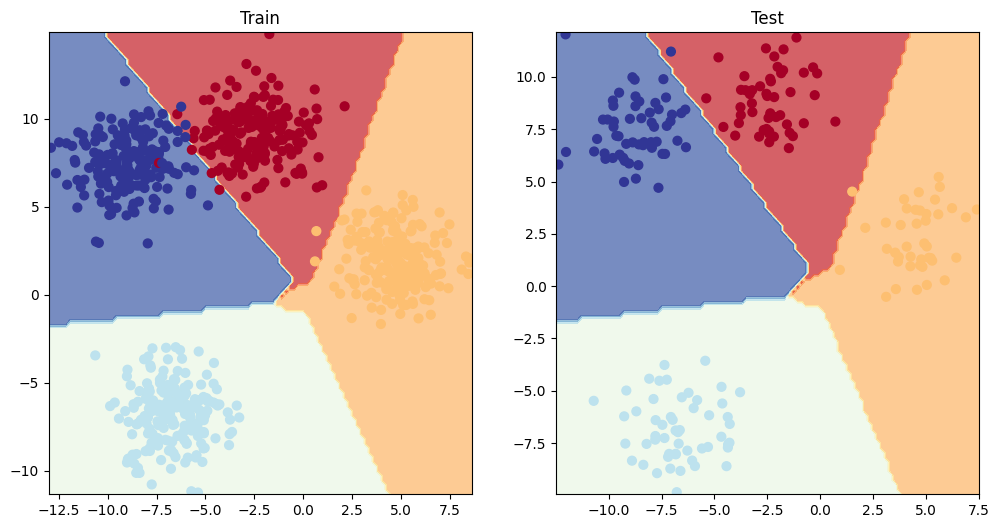

In [94]:
plt.figure(figsize = (12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_4, X_blob_train, y_blob_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_4, X_blob_test, y_blob_test)

In [95]:
# accuracy
# Precision
# Recall
# F1-score
# Confusion matrix
# Classification report